In [ ]:
import re
import sys
from pathlib import Path

import duckdb
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

ROOT_PATH = Path().resolve().parents[3]
sys.path.insert(0, str(ROOT_PATH))

In [ ]:
# ── Checkpoint ────────────────────────────────────────────────────────
# Point to either an original DA checkpoint or a finetuned checkpoint.
# The notebook looks for pre-computed prediction DBs under PREDS_DIR.
CHECKPOINT = ROOT_PATH / "experiments/numu/260508_1724_da_nu_classifier_h5s0_lambda0.01_thr0.8_seed32/best_da_model.pth"
#CHECKPOINT = ROOT_PATH / "inference_v2/nu_classifier/exp_finetuning/finetuned_models/260508_1724_da_nu_classifier_h5s0_lambda0.01_thr0.8_seed32@best_da_model_finetuned_FAIL/checkpoint_epoch_0009.pth"
# ── Paths ─────────────────────────────────────────────────────────────
PREDS_DIR   = ROOT_PATH / "inference_v2/nu_classifier/preds"
CATALOG     = ROOT_PATH / "data_manager/catalog_v2.duckdb"
EXP_H5      = ROOT_PATH / "data_manager/data/h5datasets/exp_full.h5"
MC_H5       = ROOT_PATH / "data_manager/data/h5datasets/baikal_mc_merged.h5"

# ── Sample sizes ──────────────────────────────────────────────────────
# N_EXP = None  ->  load ALL exp events from the prediction DB
# N_EXP = 10000 ->  random sample of N exp events
N_EXP       = None
N_MC        = 5_000_000     # MC muatm events to sample

# ── Quality pre-filter (applied to predictions from the DB) ───────────
MIN_SN_HITS    = 8       # minimum sig-noise filtered hits
MIN_SN_STRINGS = 2       # minimum sig-noise filtered strings

# ── Analysis ──────────────────────────────────────────────────────────
SCORE_THR      = 0.8     # threshold defining "high score"
SN_THR_TAG     = "0p8"   # tag in the DB filename  (0p8 -> threshold=0.8)

# Maximum events per source for which raw h5 hits are loaded.
# High-score events are always prioritised; remaining slots filled randomly.
FEAT_LOAD_CAP  = 20_000

SEED           = 42
STRING_DIVISOR = 36      # channel_id // 36 = string_id  (Baikal-GVD geometry)
SN_DEVICE      = "cuda:4"  # device for SN model inference; change to "cpu" if no GPU

In [21]:
# ── Discover and validate prediction DBs ─────────────────────────────
ckpt      = Path(CHECKPOINT)
ckpt_name = f"{ckpt.parent.name}@{ckpt.stem}"
ckpt_dir  = Path(PREDS_DIR) / ckpt_name
#ckpt_dir = Path(CHECKPOINT).parent

exp_db = ckpt_dir / f"exp_thr{SN_THR_TAG}.duckdb"
mc_db  = ckpt_dir / f"mc_merged_thr{SN_THR_TAG}.duckdb"

missing = []
if not exp_db.exists():
    missing.append(f"  exp  -> {exp_db}")
if not mc_db.exists():
    missing.append(f"  MC   -> {mc_db}")

if missing:
    raise FileNotFoundError(
        f"Prediction DB(s) not found for checkpoint:\n"
        f"  {CHECKPOINT}\n\n"
        f"Expected:\n" + "\n".join(missing) + "\n\n"
        f"Run the prediction scripts first:\n"
        f"  python inference_v2/nu_classifier/predict_exp.py \\\n"
        f"      --checkpoint {CHECKPOINT} \\\n"
        f"      --exp-h5 {EXP_H5} --threshold 0.8\n\n"
        f"  python inference_v2/nu_classifier/predict_mc.py \\\n"
        f"      --checkpoint {CHECKPOINT} \\\n"
        f"      --mc-h5 {MC_H5} --threshold 0.8"
    )

print(f"Checkpoint : {ckpt_name}")
print(f"Exp DB     : {exp_db}")
print(f"MC DB      : {mc_db}")

def _db_count(path):
    c = duckdb.connect(str(path), read_only=True)
    n = c.execute("SELECT COUNT(*) FROM predictions").fetchone()[0]
    c.close()
    return n

n_exp_total = _db_count(exp_db)
n_mc_total  = _db_count(mc_db)
print(f"\nTotal events in exp DB   : {n_exp_total:,}")
print(f"Total events in MC DB    : {n_mc_total:,}")

Checkpoint : 260508_1724_da_nu_classifier_h5s0_lambda0.01_thr0.8_seed32@best_da_model
Exp DB     : /home/albert/Baikal2025/inference_v2/nu_classifier/preds/260508_1724_da_nu_classifier_h5s0_lambda0.01_thr0.8_seed32@best_da_model/exp_thr0p8.duckdb
MC DB      : /home/albert/Baikal2025/inference_v2/nu_classifier/preds/260508_1724_da_nu_classifier_h5s0_lambda0.01_thr0.8_seed32@best_da_model/mc_merged_thr0p8.duckdb

Total events in exp DB   : 37,786
Total events in MC DB    : 12,091,088


In [22]:
# ── Query predictions + catalog metadata ─────────────────────────────

def _query_events(
    pred_db: Path,
    catalog: str,
    min_sn_hits: int,
    min_sn_strings: int,
    data_class_filter: str | None = None,
    limit: int | None = None,
    seed: int = 42,
    sequential: bool = False,
) -> pd.DataFrame:
    """Join prediction DB with catalog to get scores + metadata + h5 locations.

    limit + sequential=False  →  random reservoir sample (reproducible via seed)
    limit + sequential=True   →  first N rows ordered by event_fk (deterministic)
    limit=None                →  all rows (sequential flag ignored)
    """
    conn = duckdb.connect(str(pred_db), read_only=True)
    conn.execute(f"ATTACH '{catalog}' AS cat (READ_ONLY)")

    # exp has cluster column; MC does not need it but has data_class
    extra = ", e.cluster" if data_class_filter is None else ", e.data_class"

    where = (
        f"p.n_sn_hits >= {min_sn_hits} AND p.n_sn_strings >= {min_sn_strings}"
    )
    if data_class_filter:
        where += f" AND e.data_class = '{data_class_filter}'"

    if limit is None:
        tail = ""
    elif sequential:
        tail = f"ORDER BY p.event_fk LIMIT {limit}"
    else:
        tail = f"USING SAMPLE reservoir({limit} ROWS) REPEATABLE ({seed})"

    df = conn.execute(f"""
        SELECT p.event_fk, p.score, p.n_sn_hits, p.n_sn_strings,
               e.season, e.run AS run_num, e.event_id{extra},
               l.h5_path, l.part_key, l.local_idx
        FROM predictions p
        JOIN cat.events       e ON e.id       = p.event_fk
        JOIN cat.h5_locations l ON l.event_fk = p.event_fk
        WHERE {where}
        {tail}
    """).df()
    conn.execute("DETACH cat")
    conn.close()
    return df


print("Querying exp events ...")
df_exp = _query_events(
    exp_db, CATALOG,
    min_sn_hits=MIN_SN_HITS, min_sn_strings=MIN_SN_STRINGS,
    limit=N_EXP, seed=SEED,
)

print("Querying MC muatm events ...")
df_mc = _query_events(
    mc_db, CATALOG,
    min_sn_hits=MIN_SN_HITS, min_sn_strings=MIN_SN_STRINGS,
    data_class_filter="muatm_2020",
    limit=N_MC, seed=SEED,
    sequential=True,   # set True to load first N events by event_fk instead of random
)

print(f"\nLoaded {len(df_exp):,} exp events       ({df_exp['part_key'].nunique()} parts)")
print(f"Loaded {len(df_mc):,}  MC muatm events  ({df_mc['part_key'].nunique()} parts)")
print(f"\nExp  score > {SCORE_THR}: {(df_exp.score > SCORE_THR).sum():,}  "
      f"({100*(df_exp.score > SCORE_THR).mean():.1f}%)")
print(f"MC   score > {SCORE_THR}: {(df_mc.score  > SCORE_THR).sum():,}  "
      f"({100*(df_mc.score  > SCORE_THR).mean():.1f}%)")


Querying exp events ...
Querying MC muatm events ...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Loaded 20,191 exp events       (26 parts)
Loaded 2,618,304  MC muatm events  (763 parts)

Exp  score > 0.8: 25  (0.1%)
MC   score > 0.8: 470  (0.0%)


In [5]:
470/2_618_304 * 20_191

3.6243957920852585

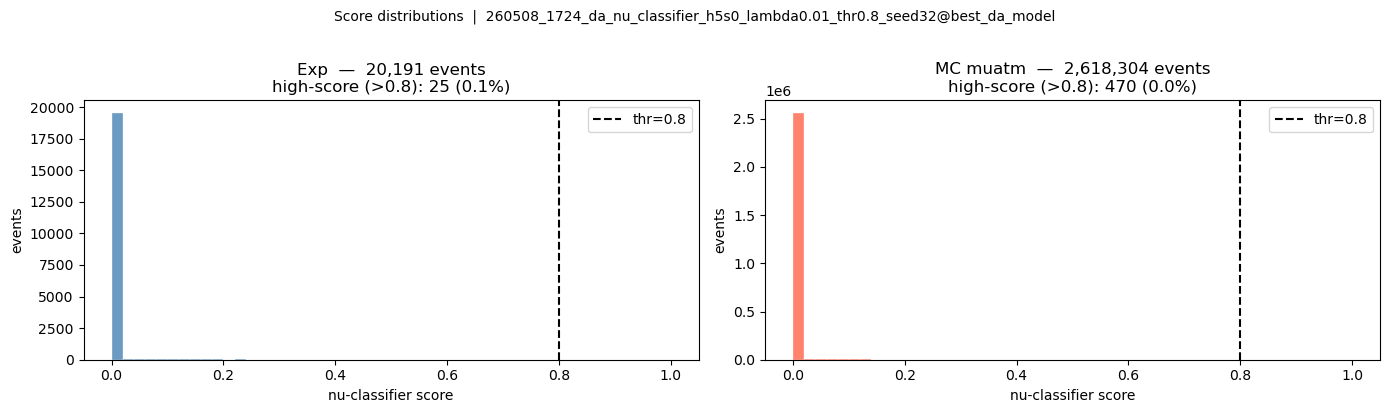

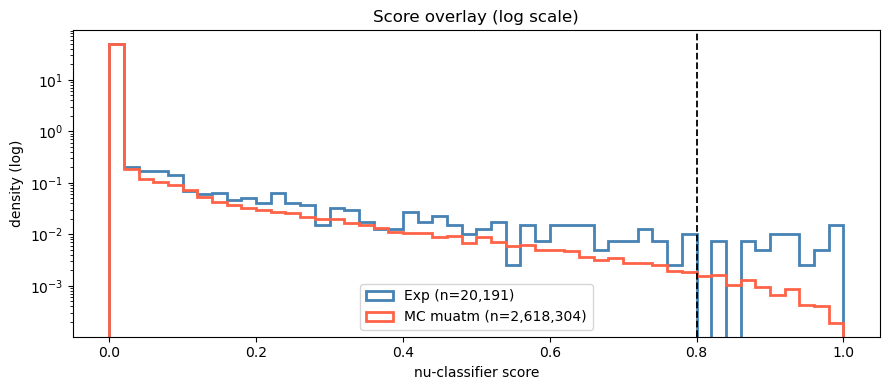

In [23]:
# ── Score distributions (DB data only, no h5 loading) ─────────────────
bins = np.linspace(0, 1, 51)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, df, label, color in [
    (axes[0], df_exp, "Exp",      "steelblue"),
    (axes[1], df_mc,  "MC muatm", "tomato"),
]:
    ax.hist(df.score, bins=bins, color=color, alpha=0.8, edgecolor="white", linewidth=0.3)
    ax.axvline(SCORE_THR, color="black", lw=1.5, ls="--", label=f"thr={SCORE_THR}")
    hi = (df.score > SCORE_THR).sum()
    ax.set_title(
        f"{label}  —  {len(df):,} events\n"
        f"high-score (>{SCORE_THR}): {hi:,} ({100*hi/len(df):.1f}%)"
    )
    ax.set_xlabel("nu-classifier score")
    ax.set_ylabel("events")
    ax.legend()

plt.suptitle(f"Score distributions  |  {ckpt_name}", y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

# Overlay (log-scale)
fig, ax = plt.subplots(figsize=(9, 4))
kw = dict(bins=bins, density=True, histtype="step", linewidth=2)
ax.hist(df_exp.score, **kw, color="steelblue", label=f"Exp (n={len(df_exp):,})")
ax.hist(df_mc.score,  **kw, color="tomato",    label=f"MC muatm (n={len(df_mc):,})")
ax.axvline(SCORE_THR, color="black", lw=1.3, ls="--")
ax.set_yscale("log")
ax.set_xlabel("nu-classifier score")
ax.set_ylabel("density (log)")
ax.set_title("Score overlay (log scale)")
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
# ── Load raw hits from h5 ─────────────────────────────────────────────
# High-score events are always included; remaining FEAT_LOAD_CAP slots
# are filled with a random low-score sample.

def _select_for_feature_load(
    df: pd.DataFrame, cap: int, score_thr: float, seed: int
) -> pd.DataFrame:
    if len(df) <= cap:
        return df.copy()
    high = df[df.score >  score_thr]
    low  = df[df.score <= score_thr]
    n_low = max(0, cap - len(high))
    if n_low > 0 and len(low) > n_low:
        low = low.sample(n_low, random_state=seed)
    return pd.concat([high, low], ignore_index=True)


df_exp_feat = _select_for_feature_load(df_exp, FEAT_LOAD_CAP, SCORE_THR, SEED)
df_mc_feat  = _select_for_feature_load(df_mc,  FEAT_LOAD_CAP, SCORE_THR, SEED)
print(f"Loading raw hits for {len(df_exp_feat):,} exp events and "
      f"{len(df_mc_feat):,} MC events")


def _compute_raw_stats(hits: np.ndarray, channels: np.ndarray) -> dict:
    n = len(hits)
    _nan = {k: np.nan for k in [
        "n_raw_hits", "n_raw_strings",
        "q_max", "q_mean", "q_std", "q_sum", "q_p99",
        "t_min", "t_max", "t_std", "t_range",
        "x_std", "y_std", "z_std", "spatial_std",
    ]}
    if n == 0:
        return _nan
    q = hits[:, 0]; t = hits[:, 1]
    x = hits[:, 2]; y = hits[:, 3]; z = hits[:, 4]
    return {
        "n_raw_hits":    n,
        "n_raw_strings": int(len(np.unique(channels // STRING_DIVISOR))),
        "q_max":         float(q.max()),
        "q_mean":        float(q.mean()),
        "q_std":         float(q.std()),
        "q_sum":         float(q.sum()),
        "q_p99":         float(np.percentile(q, 99)),
        "t_min":         float(t.min()),
        "t_max":         float(t.max()),
        "t_std":         float(t.std()),
        "t_range":       float(t.max() - t.min()),
        "x_std":         float(x.std()),
        "y_std":         float(y.std()),
        "z_std":         float(z.std()),
        "spatial_std":   float(np.sqrt(x.var() + y.var() + z.var())),
    }


def load_hits_for_events(
    df: pd.DataFrame,
    grp_name: str,
    load_mc_truth: bool = False,
    keep_raw: bool = False,
) -> pd.DataFrame | tuple:
    """Load raw hits part-by-part, compute per-event stats.

    When keep_raw=True, returns (stats_df, raw_hits_list, raw_channels_list)
    where raw_hits_list[i] and raw_channels_list[i] correspond to stats_df.iloc[i].
    """
    rows              = []
    raw_hits_list     = [] if keep_raw else None
    raw_channels_list = [] if keep_raw else None

    groups = df.groupby(["h5_path", "part_key"], sort=True)
    for (h5_path, part_key), grp_df in tqdm(groups, desc=f"{grp_name} parts"):
        with h5py.File(h5_path, "r") as f:
            h5g       = f[grp_name]
            ev_starts = h5g[f"raw/ev_starts/{part_key}/data"][:].astype(np.int64)
            data_raw  = h5g[f"raw/data/{part_key}/data"][:].astype(np.float32)
            channels  = h5g[f"raw/channels/{part_key}/data"][:].astype(np.int32)
            mc_prime  = (
                h5g[f"prime_prty/{part_key}/data"][:].astype(np.float32)
                if load_mc_truth else None
            )
            mc_mu_agg = (
                h5g[f"muons_prty/aggregate/{part_key}/data"][:].astype(np.float32)
                if load_mc_truth else None
            )

        for row in grp_df.itertuples(index=False):
            li    = int(row.local_idx)
            s, e  = int(ev_starts[li]), int(ev_starts[li + 1])
            hits  = data_raw[s:e]
            chans = channels[s:e]

            r = _compute_raw_stats(hits, chans)
            r["event_fk"]     = int(row.event_fk)
            r["score"]        = float(row.score)
            r["n_sn_hits"]    = int(row.n_sn_hits)
            r["n_sn_strings"] = int(row.n_sn_strings)
            r["sn_ratio"]     = row.n_sn_hits / max(e - s, 1)

            if load_mc_truth and mc_prime is not None:
                r["theta"]          = float(mc_prime[li, 0])
                r["phi"]            = float(mc_prime[li, 1])
                r["energy_primary"] = float(mc_prime[li, 2])
                r["energy_bundle"]  = float(mc_mu_agg[li, 1])

            rows.append(r)
            if keep_raw:
                raw_hits_list.append(hits.copy())
                raw_channels_list.append(chans.copy())

    stats = pd.DataFrame(rows)
    if keep_raw:
        return stats, raw_hits_list, raw_channels_list
    return stats


print("\nLoading exp raw hits ...")
stats_exp, raw_hits_exp, raw_chans_exp = load_hits_for_events(
    df_exp_feat, grp_name="exp", load_mc_truth=False, keep_raw=True,
)
print("\nLoading MC raw hits ...")
stats_mc, raw_hits_mc, raw_chans_mc = load_hits_for_events(
    df_mc_feat, grp_name="muatm_2020", load_mc_truth=True, keep_raw=True,
)
print(f"\nstats_exp: {stats_exp.shape}")
print(f"stats_mc:  {stats_mc.shape}")
stats_exp.head(3)

Loading raw hits for 20,000 exp events and 20,000 MC events

Loading exp raw hits ...


exp parts:   0%|          | 0/26 [00:00<?, ?it/s]


Loading MC raw hits ...


muatm_2020 parts:   0%|          | 0/763 [00:00<?, ?it/s]


stats_exp: (20000, 20)
stats_mc:  (20000, 24)


,n_raw_hits,n_raw_strings,q_max,q_mean,q_std,q_sum,q_p99,t_min,t_max,t_std,t_range,x_std,y_std,z_std,spatial_std,event_fk,score,n_sn_hits,n_sn_strings,sn_ratio
0,64,7,30.442957,2.007488,3.931555,128.479202,18.250040,-2425.703857,2215.300049,1165.988281,4641.003906,39.290257,30.261326,131.459045,140.502502,656215674,0.000500,12,5,0.187500
1,71,7,10.114654,1.388404,1.541042,98.576706,8.502033,-2328.863037,2548.456299,1174.218018,4877.319336,42.577991,32.038139,166.646194,174.957947,656208487,0.001160,8,3,0.112676
2,92,7,70.636574,2.390355,8.023564,219.912689,37.664116,-2490.943359,2468.429688,1276.416016,4959.373047,38.810841,32.961388,113.738716,124.616333,656196007,0.000654,13,4,0.141304


In [25]:
# ── SN-model filtering: compute signal-hit statistics ─────────────────
import torch
from inference_v2.shared.model_utils import load_sn_model
from gplotnikov_sig_noise_models.k_nsol_labelneq0_da_hs128_k0p0001.sig_noise_model_v3 import (
    predict_flat as _sn_predict_flat,
)

SN_THRESHOLD = float(SN_THR_TAG.replace("p", "."))   # "0p8" → 0.8

print(f"Loading SN model on {SN_DEVICE} ...")
_sn_nn, _sn_cfg, _sn_dev = load_sn_model(device=SN_DEVICE)
print(f"SN model ready on {_sn_dev}  |  threshold = {SN_THRESHOLD}")


def compute_sn_filtered_stats(
    stats_df: pd.DataFrame,
    raw_hits_list: list,
    raw_channels_list: list,
    desc: str = "",
) -> pd.DataFrame:
    """Run SN model on collected raw hits; compute stats on signal hits only.

    Concatenates all events into a flat array for efficient batch inference,
    then splits the per-hit probabilities back per event and applies SN_THRESHOLD.
    The row order matches stats_df exactly (same index correspondence).
    """
    flat_data = np.concatenate(raw_hits_list, axis=0)
    ev_lens   = np.array([len(h) for h in raw_hits_list], dtype=np.int64)
    ev_starts = np.concatenate([[0], np.cumsum(ev_lens)]).astype(np.int64)

    probs = _sn_predict_flat(
        _sn_nn, flat_data, ev_starts,
        batch_size=512, device=torch.device(_sn_dev),
        normalize=True, desc=desc,
    )

    rows = []
    for i, (s, e) in enumerate(zip(ev_starts[:-1], ev_starts[1:])):
        sig_mask = probs[s:e] >= SN_THRESHOLD
        r = _compute_raw_stats(raw_hits_list[i][sig_mask], raw_channels_list[i][sig_mask])
        r["event_fk"] = int(stats_df.iloc[i]["event_fk"])
        r["score"]    = float(stats_df.iloc[i]["score"])
        rows.append(r)

    return pd.DataFrame(rows)


print("\nRunning SN filter on exp hits ...")
stats_exp_sn = compute_sn_filtered_stats(stats_exp, raw_hits_exp, raw_chans_exp, desc="exp SN")
print("Running SN filter on MC hits ...")
stats_mc_sn  = compute_sn_filtered_stats(stats_mc,  raw_hits_mc,  raw_chans_mc,  desc="MC SN")

print(f"\nSignal hit counts after SN filter (threshold={SN_THRESHOLD}):")
print(f"  Exp — mean {stats_exp_sn['n_raw_hits'].mean():.1f} hits/event"
      f"  (raw: {stats_exp['n_raw_hits'].mean():.1f})")
print(f"  MC  — mean {stats_mc_sn['n_raw_hits'].mean():.1f} hits/event"
      f"  (raw: {stats_mc['n_raw_hits'].mean():.1f})")

/home/albert/Baikal2025/gplotnikov_sig_noise_models/k_nsol_labelneq0_da_hs128_k0p0001/model_simplified.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.enc = nn.TransformerEncoder(enc_layer, num_layers)


Loading SN model on cuda:1 ...
SN model ready on cuda:1  |  threshold = 0.8

Running SN filter on exp hits ...


exp SN (20000 ev): 100%|██████████| 20000/20000 [00:01<00:00, 15836.32it/s]


Running SN filter on MC hits ...


MC SN (20000 ev): 100%|██████████| 20000/20000 [00:00<00:00, 20491.66it/s]



Signal hit counts after SN filter (threshold=0.8):
  Exp — mean 13.7 hits/event  (raw: 80.0)
  MC  — mean 13.5 hits/event  (raw: 78.9)


In [26]:
# ── Score bands ───────────────────────────────────────────────────────
# Adjust SCORE_THR here and re-run cells below to update all plots.
SCORE_THR = 0.8

exp_hi = stats_exp[stats_exp.score >  SCORE_THR]
exp_lo = stats_exp[stats_exp.score <= SCORE_THR]
mc_hi  = stats_mc [stats_mc.score  >  SCORE_THR]
mc_lo  = stats_mc [stats_mc.score  <= SCORE_THR]

print(f"Exp  high: {len(exp_hi):,}   low: {len(exp_lo):,}")
print(f"MC   high: {len(mc_hi):,}   low: {len(mc_lo):,}")

Exp  high: 25   low: 19,975
MC   high: 470   low: 19,530


/tmp/ipykernel_2121912/57168953.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


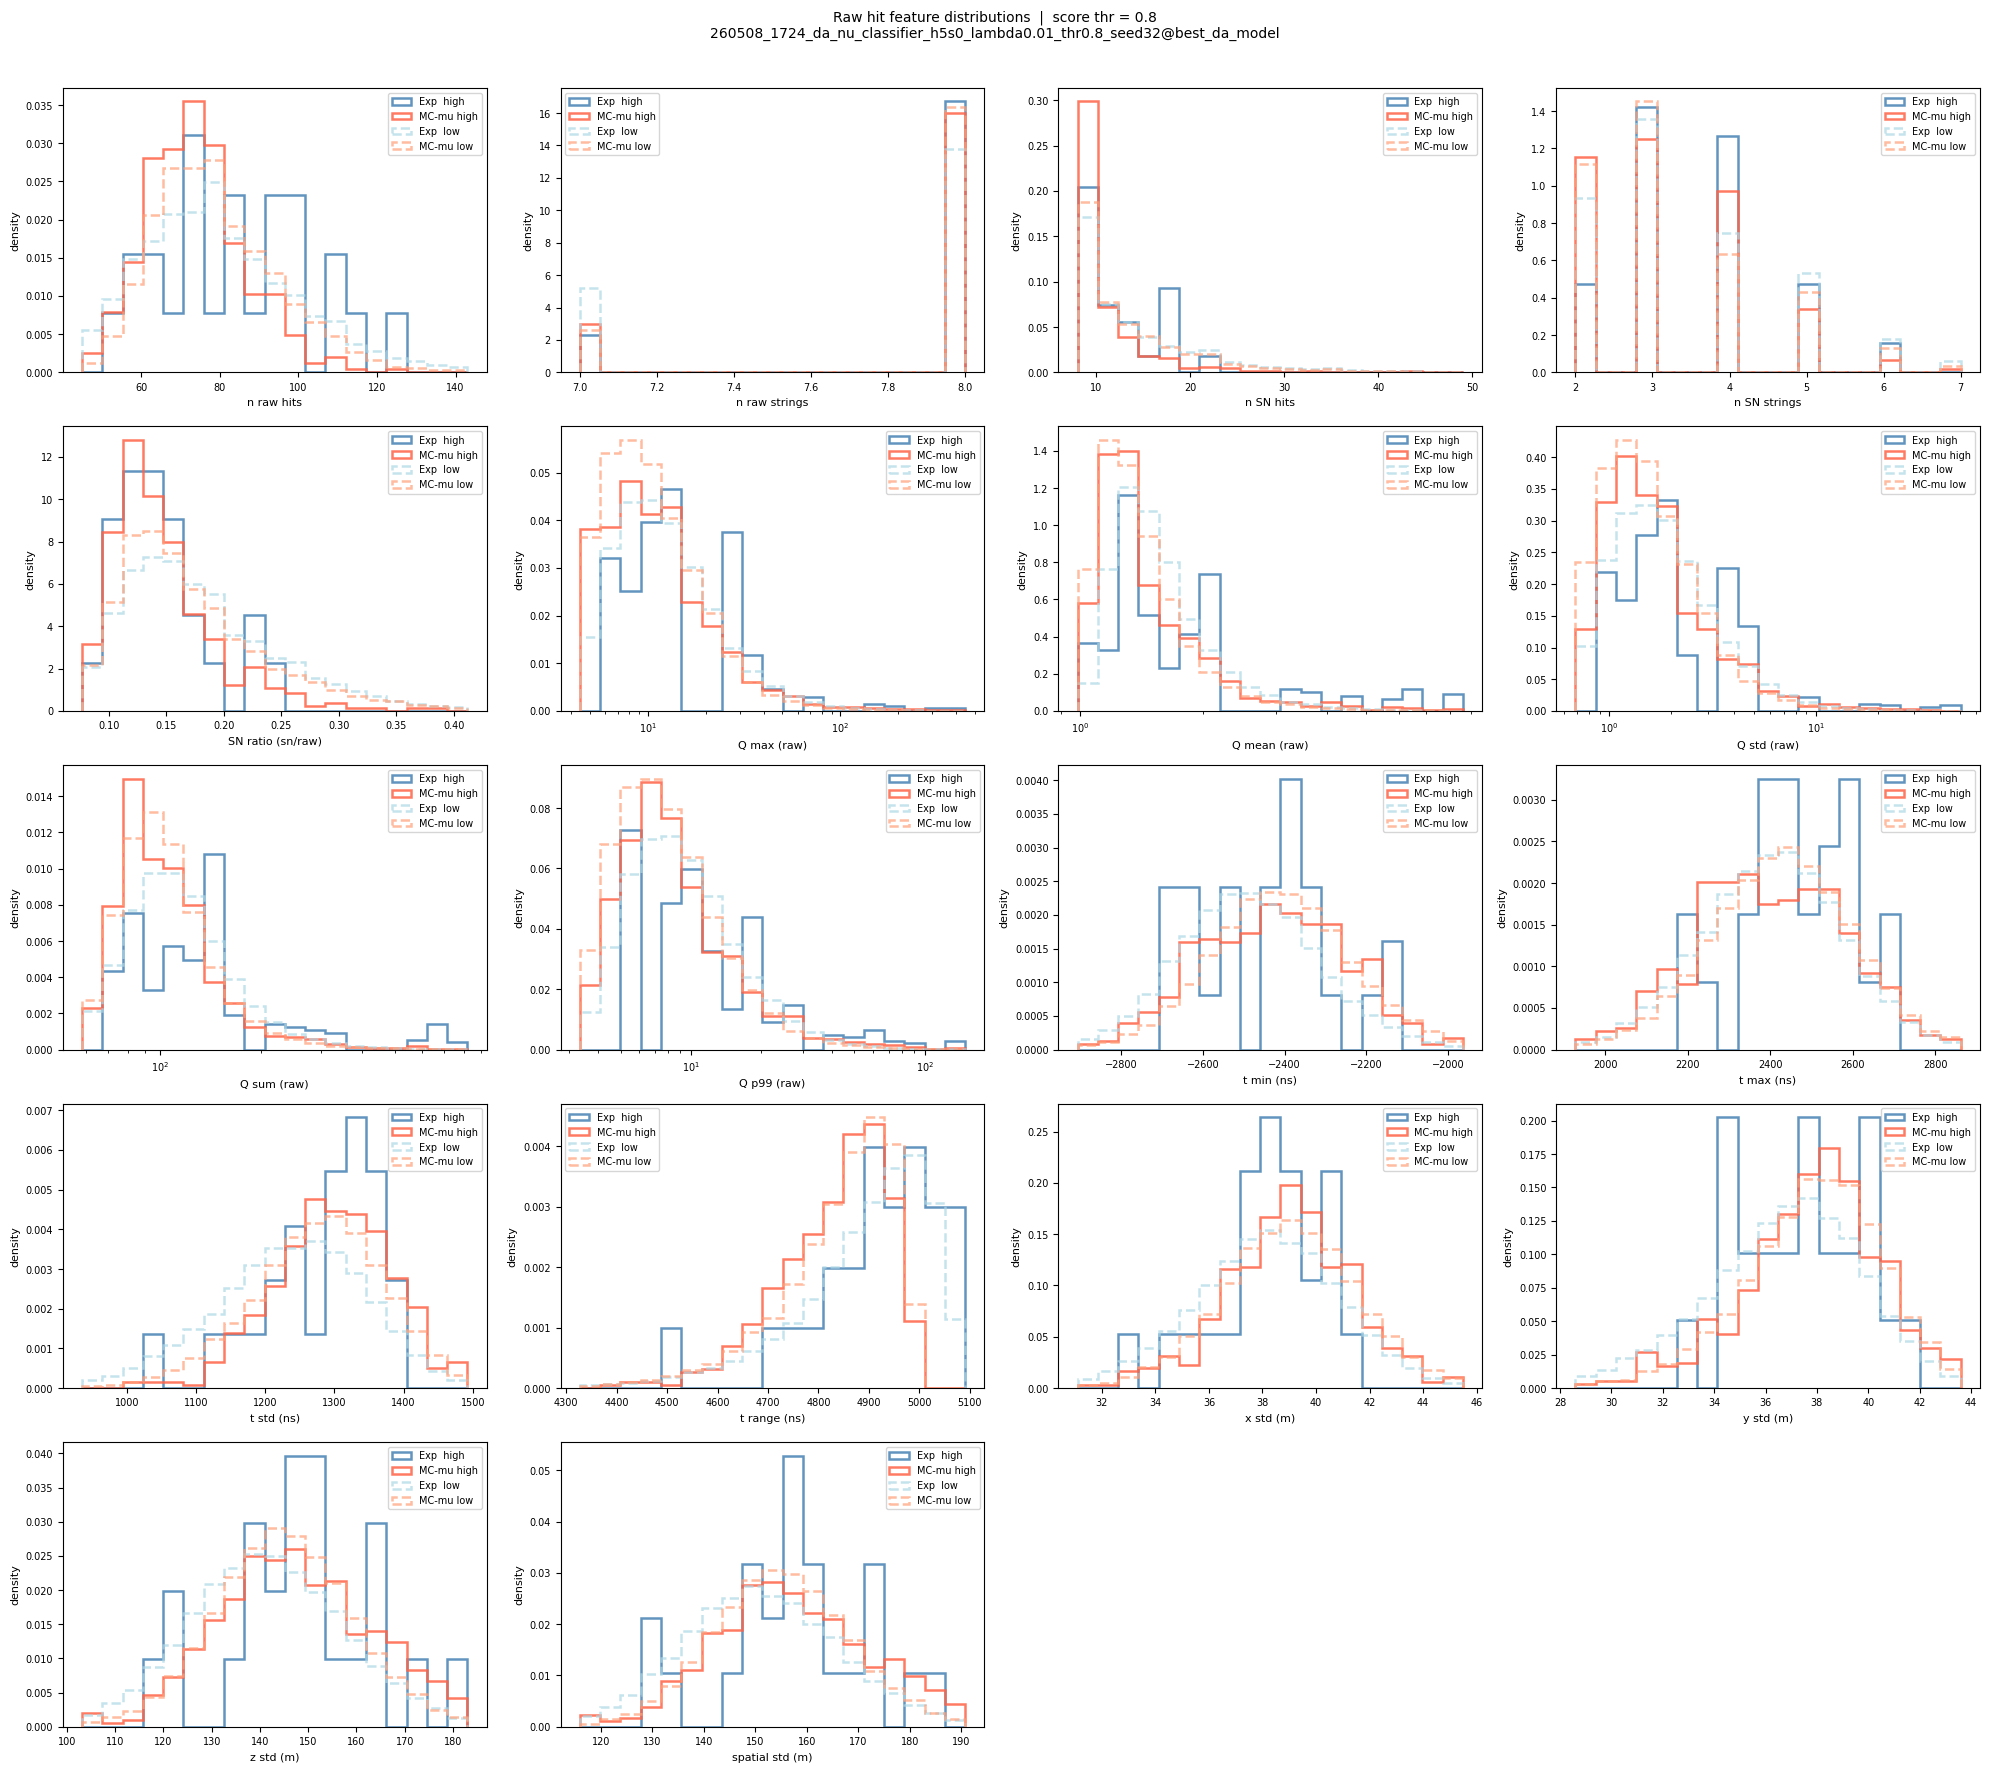

In [27]:
# ── Feature distributions: high-score Exp vs high-score MC muatm ─────
FEATURES = [
    # (column,          xlabel,                       log_x)
    ("n_raw_hits",      "n raw hits",                 False),
    ("n_raw_strings",   "n raw strings",              False),
    ("n_sn_hits",       "n SN hits",                  False),
    ("n_sn_strings",    "n SN strings",               False),
    ("sn_ratio",        "SN ratio (sn/raw)",          False),
    ("q_max",           "Q max (raw)",                True),
    ("q_mean",          "Q mean (raw)",               True),
    ("q_std",           "Q std (raw)",                True),
    ("q_sum",           "Q sum (raw)",                True),
    ("q_p99",           "Q p99 (raw)",                True),
    ("t_min",           "t min (ns)",                 False),
    ("t_max",           "t max (ns)",                 False),
    ("t_std",           "t std (ns)",                 False),
    ("t_range",         "t range (ns)",               False),
    ("x_std",           "x std (m)",                  False),
    ("y_std",           "y std (m)",                  False),
    ("z_std",           "z std (m)",                  False),
    ("spatial_std",     "spatial std (m)",            False),
]

GROUPS = [
    (exp_hi, "Exp  high",    "steelblue",   0.85, "-"),
    (mc_hi,  "MC-mu high",   "tomato",      0.85, "-"),
    (exp_lo, "Exp  low",     "lightblue",   0.7, "--"),
    (mc_lo,  "MC-mu low",    "lightsalmon", 0.7, "--"),
]

n_cols = 4
n_rows = (len(FEATURES) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, (col, xlabel, log_x) in enumerate(FEATURES):
    ax = axes[i]
    all_vals = pd.concat([g[col].dropna() for g, *_ in GROUPS])
    lo_p = np.percentile(all_vals, 0.5)
    hi_p = np.percentile(all_vals, 99.5)

    if log_x and lo_p > 0:
        bins = np.logspace(np.log10(max(lo_p, 1e-9)), np.log10(hi_p), 20)
        ax.set_xscale("log")
    else:
        bins = np.linspace(lo_p, hi_p, 20)

    for df_g, label, color, alpha, ls in GROUPS:
        vals = df_g[col].dropna()
        if len(vals) == 0:
            continue
        ax.hist(vals, bins=bins, density=True, histtype="step",
                color=color, alpha=alpha, linewidth=1.8, linestyle=ls, label=label)

    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel("density", fontsize=8)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
for ax in axes:
    ax.legend(fontsize=7)
fig.suptitle(
    f"Raw hit feature distributions  |  score thr = {SCORE_THR}\n{ckpt_name}",
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.show()

Exp  high (SN): 25   low: 19,975
MC   high (SN): 470   low: 19,530


/tmp/ipykernel_2121912/1585805009.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


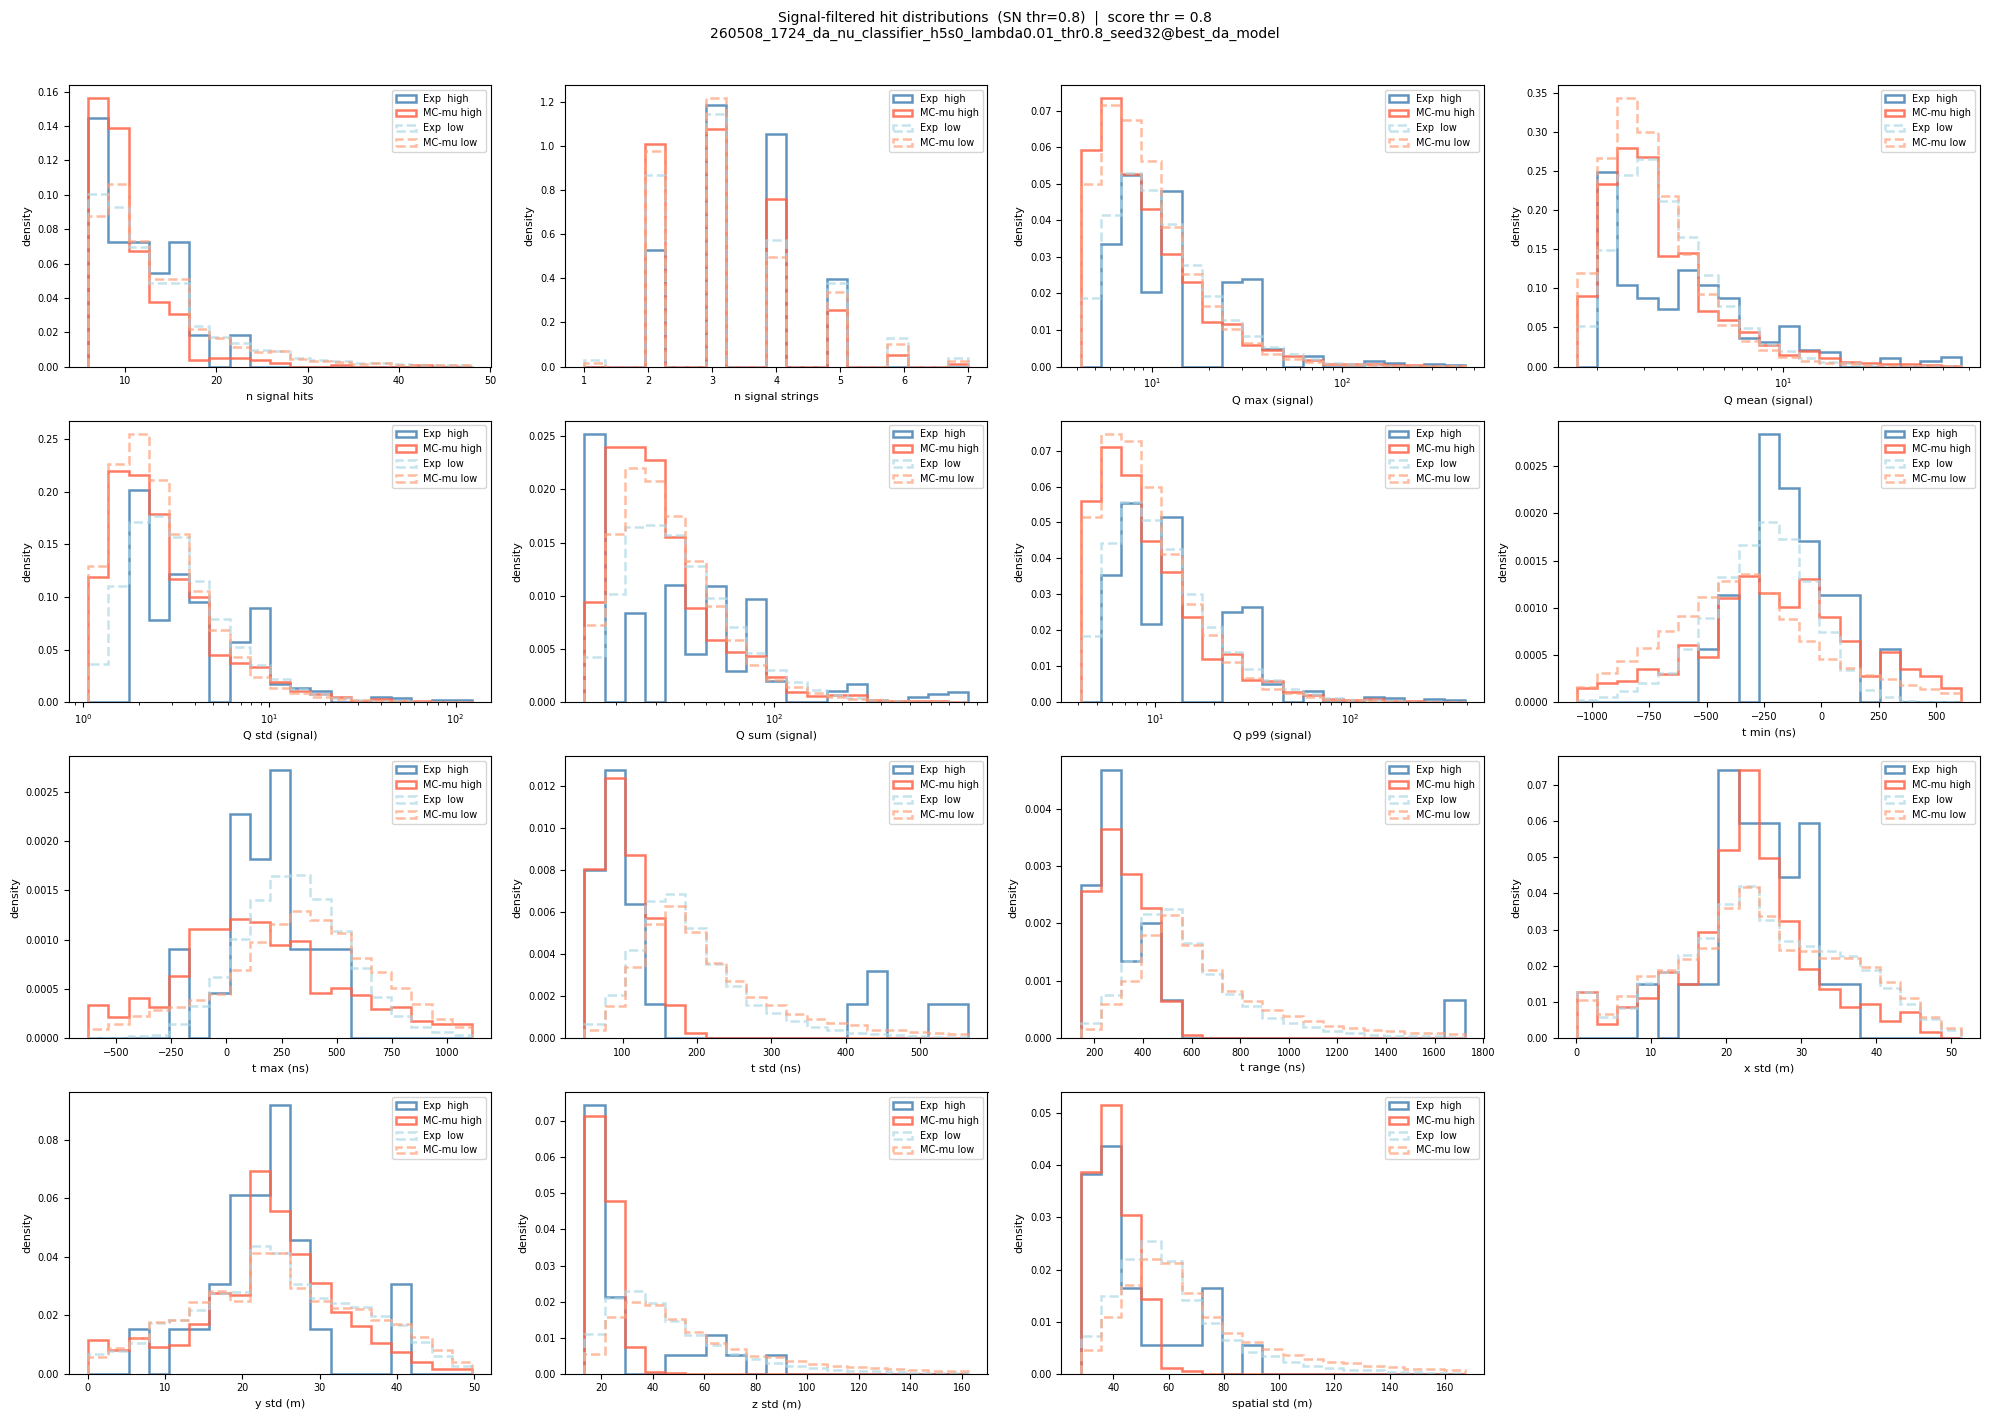

In [28]:
# ── Signal-filtered feature distributions ─────────────────────────────
# Same layout as raw distributions above, but using only SN-model-selected hits.
# MC noise-hit modelling is imperfect; signal-only comparison isolates genuine
# differences from noise modelling artefacts — the nu-classifier sees these hits.

hi_fks_exp = set(exp_hi.event_fk)
hi_fks_mc  = set(mc_hi.event_fk)
exp_hi_sn  = stats_exp_sn[stats_exp_sn.event_fk.isin(hi_fks_exp)]
mc_hi_sn   = stats_mc_sn [stats_mc_sn.event_fk.isin(hi_fks_mc)]
exp_lo_sn  = stats_exp_sn[~stats_exp_sn.event_fk.isin(hi_fks_exp)]
mc_lo_sn   = stats_mc_sn [~stats_mc_sn.event_fk.isin(hi_fks_mc)]

print(f"Exp  high (SN): {len(exp_hi_sn):,}   low: {len(exp_lo_sn):,}")
print(f"MC   high (SN): {len(mc_hi_sn):,}   low: {len(mc_lo_sn):,}")

FEATURES_SN = [
    # (column,          xlabel,                       log_x)
    ("n_raw_hits",    "n signal hits",                False),
    ("n_raw_strings", "n signal strings",             False),
    ("q_max",         "Q max (signal)",               True),
    ("q_mean",        "Q mean (signal)",              True),
    ("q_std",         "Q std (signal)",               True),
    ("q_sum",         "Q sum (signal)",               True),
    ("q_p99",         "Q p99 (signal)",               True),
    ("t_min",         "t min (ns)",                   False),
    ("t_max",         "t max (ns)",                   False),
    ("t_std",         "t std (ns)",                   False),
    ("t_range",       "t range (ns)",                 False),
    ("x_std",         "x std (m)",                    False),
    ("y_std",         "y std (m)",                    False),
    ("z_std",         "z std (m)",                    False),
    ("spatial_std",   "spatial std (m)",              False),
]

GROUPS_SN = [
    (exp_hi_sn, "Exp  high",    "steelblue",   0.85, "-"),
    (mc_hi_sn,  "MC-mu high",   "tomato",      0.85, "-"),
    (exp_lo_sn, "Exp  low",     "lightblue",   0.7,  "--"),
    (mc_lo_sn,  "MC-mu low",    "lightsalmon", 0.7,  "--"),
]

n_cols = 4
n_rows = (len(FEATURES_SN) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, (col, xlabel, log_x) in enumerate(FEATURES_SN):
    ax = axes[i]
    all_vals = pd.concat([g[col].dropna() for g, *_ in GROUPS_SN])
    if len(all_vals) == 0:
        axes[i].set_visible(False)
        continue
    lo_p = np.percentile(all_vals, 0.5)
    hi_p = np.percentile(all_vals, 99.5)

    if log_x and lo_p > 0:
        bins = np.logspace(np.log10(max(lo_p, 1e-9)), np.log10(hi_p), 20)
        ax.set_xscale("log")
    else:
        bins = np.linspace(lo_p, hi_p, 20)

    for df_g, label, color, alpha, ls in GROUPS_SN:
        vals = df_g[col].dropna()
        if len(vals) == 0:
            continue
        ax.hist(vals, bins=bins, density=True, histtype="step",
                color=color, alpha=alpha, linewidth=1.8, linestyle=ls, label=label)

    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel("density", fontsize=8)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
for ax in axes:
    ax.legend(fontsize=7)
fig.suptitle(
    f"Signal-filtered hit distributions  (SN thr={SN_THRESHOLD})  |  score thr = {SCORE_THR}\n{ckpt_name}",
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.show()

In [31]:
# ── df_hi: comprehensive table of high-score exp events ────────────────
# Scalar columns : metadata + raw hit stats + SN-filtered stats (_sn suffix)
# Array columns  (all parallel to raw_hits unless noted):
#   raw_hits     (n_raw, 5)  — raw hit features [q, t, x, y, z]
#   raw_channels (n_raw,)    — channel_id per raw hit
#   sn_probs     (n_raw,)    — SN model probability per raw hit
#   sn_hits      (n_sn, 5)   — signal-filtered hit features (sn_probs >= SN_THRESHOLD)
#   sn_channels  (n_sn,)     — channel_id per signal hit

# --- 1. ordered list of high-score event_fks
hi_fks = list(exp_hi["event_fk"].astype(int))

# --- 2. event_fk → position in stats_exp / raw_hits_exp / raw_chans_exp
fk_to_idx = {int(fk): i for i, fk in enumerate(stats_exp["event_fk"])}

# --- 3. pull raw arrays for high-score events (no h5 reload needed)
_hi_raw_hits  = [raw_hits_exp [fk_to_idx[fk]] for fk in hi_fks]
_hi_raw_chans = [raw_chans_exp[fk_to_idx[fk]] for fk in hi_fks]

# --- 4. batch SN inference on high-score events only → per-raw-hit probabilities
print(f"Running SN inference on {len(hi_fks):,} high-score exp events ...")
_flat   = np.concatenate(_hi_raw_hits, axis=0)
_lens   = np.array([len(h) for h in _hi_raw_hits], dtype=np.int64)
_starts = np.concatenate([[0], np.cumsum(_lens)]).astype(np.int64)
_probs  = _sn_predict_flat(
    _sn_nn, _flat, _starts,
    batch_size=512, device=torch.device(_sn_dev),
    normalize=True, desc="df_hi SN",
)

# split per event: sn_probs covers ALL raw hits; sn_hits/sn_channels are the filtered subset
_sn_probs_list = []
_sn_hits_list  = []
_sn_chans_list = []
for i, (s, e) in enumerate(zip(_starts[:-1], _starts[1:])):
    p    = _probs[s:e]            # shape (n_raw,) — parallel to raw_hits[i]
    mask = p >= SN_THRESHOLD
    _sn_probs_list.append(p)
    _sn_hits_list.append (_hi_raw_hits[i][mask])   # shape (n_sn, 5)
    _sn_chans_list.append(_hi_raw_chans[i][mask])  # shape (n_sn,)

# --- 5. scalar tables (filtered to hi events)
_hi_set = set(hi_fks)

META_COLS = [c for c in ["event_fk", "score", "n_sn_hits", "n_sn_strings",
                          "season", "run_num", "event_id", "cluster",
                          "h5_path", "part_key", "local_idx"]
             if c in df_exp_feat.columns]
_meta = df_exp_feat[df_exp_feat["event_fk"].isin(_hi_set)][META_COLS].copy()

# raw stats — drop columns already present in _meta to avoid duplication
_raw = (stats_exp[stats_exp["event_fk"].isin(_hi_set)]
        .drop(columns=["score", "n_sn_hits", "n_sn_strings"], errors="ignore")
        .copy())

# SN-filtered stats — rename to _sn suffix
_sn_rename = {}
for c in stats_exp_sn.columns:
    if   c == "event_fk":      _sn_rename[c] = c
    elif c == "n_raw_hits":    _sn_rename[c] = "n_hits_sn"
    elif c == "n_raw_strings": _sn_rename[c] = "n_strings_sn"
    else:                      _sn_rename[c] = f"{c}_sn"
_sn = (stats_exp_sn[stats_exp_sn["event_fk"].isin(_hi_set)]
       .rename(columns=_sn_rename)
       .drop(columns=["score_sn"], errors="ignore")
       .copy())

# --- 6. merge scalar data on event_fk
df_hi = (
    _meta
    .merge(_raw, on="event_fk", how="inner")
    .merge(_sn,  on="event_fk", how="inner")
    .reset_index(drop=True)
)

# --- 7. attach array columns
_fk_to_i = {fk: i for i, fk in enumerate(hi_fks)}
df_hi["raw_hits"]     = [_hi_raw_hits  [_fk_to_i[fk]] for fk in df_hi["event_fk"]]
df_hi["raw_channels"] = [_hi_raw_chans [_fk_to_i[fk]] for fk in df_hi["event_fk"]]
df_hi["sn_probs"]     = [_sn_probs_list[_fk_to_i[fk]] for fk in df_hi["event_fk"]]
df_hi["sn_hits"]      = [_sn_hits_list [_fk_to_i[fk]] for fk in df_hi["event_fk"]]
df_hi["sn_channels"]  = [_sn_chans_list[_fk_to_i[fk]] for fk in df_hi["event_fk"]]

_arr_cols    = ["raw_hits", "raw_channels", "sn_probs", "sn_hits", "sn_channels"]
_scalar_cols = [c for c in df_hi.columns if c not in _arr_cols]

print(f"\ndf_hi: {len(df_hi):,} rows  |  {df_hi.shape[1]} columns")
print(f"Scalar ({len(_scalar_cols)}): {_scalar_cols}")
print(f"Array  ({len(_arr_cols)}):  {_arr_cols}")
df_hi[_scalar_cols].head(3)

Running SN inference on 25 high-score exp events ...


df_hi SN (25 ev): 100%|██████████| 25/25 [00:00<00:00, 3046.59it/s]


df_hi: 25 rows  |  47 columns
Scalar (42): ['event_fk', 'score', 'n_sn_hits', 'n_sn_strings', 'season', 'run_num', 'event_id', 'cluster', 'h5_path', 'part_key', 'local_idx', 'n_raw_hits', 'n_raw_strings', 'q_max', 'q_mean', 'q_std', 'q_sum', 'q_p99', 't_min', 't_max', 't_std', 't_range', 'x_std', 'y_std', 'z_std', 'spatial_std', 'sn_ratio', 'n_hits_sn', 'n_strings_sn', 'q_max_sn', 'q_mean_sn', 'q_std_sn', 'q_sum_sn', 'q_p99_sn', 't_min_sn', 't_max_sn', 't_std_sn', 't_range_sn', 'x_std_sn', 'y_std_sn', 'z_std_sn', 'spatial_std_sn']
Array  (5):  ['raw_hits', 'raw_channels', 'sn_probs', 'sn_hits', 'sn_channels']


,event_fk,score,n_sn_hits,n_sn_strings,season,run_num,event_id,cluster,h5_path,part_key,...,q_sum_sn,q_p99_sn,t_min_sn,t_max_sn,t_std_sn,t_range_sn,x_std_sn,y_std_sn,z_std_sn,spatial_std_sn
0,656644582,0.896379,10,5,2020,32,2286,6,/home/albert/Baikal2025/data_manager/data/h5da...,part_s2020_c06_r0032,...,76.991096,29.269243,-68.106445,125.327148,78.070152,193.433594,29.791229,24.255766,9.978226,39.691620
1,656275632,0.860265,9,2,2020,15,8312,2,/home/albert/Baikal2025/data_manager/data/h5da...,part_s2020_c02_r0015,...,80.711365,30.277803,-101.136810,203.992096,104.933685,305.128906,15.838168,20.643291,19.865448,32.735744
2,656650842,0.918340,17,4,2020,32,8546,6,/home/albert/Baikal2025/data_manager/data/h5da...,part_s2020_c06_r0032,...,82.517685,28.709616,-34.281033,322.291229,85.675797,356.572266,28.130669,21.907274,19.572058,40.673439


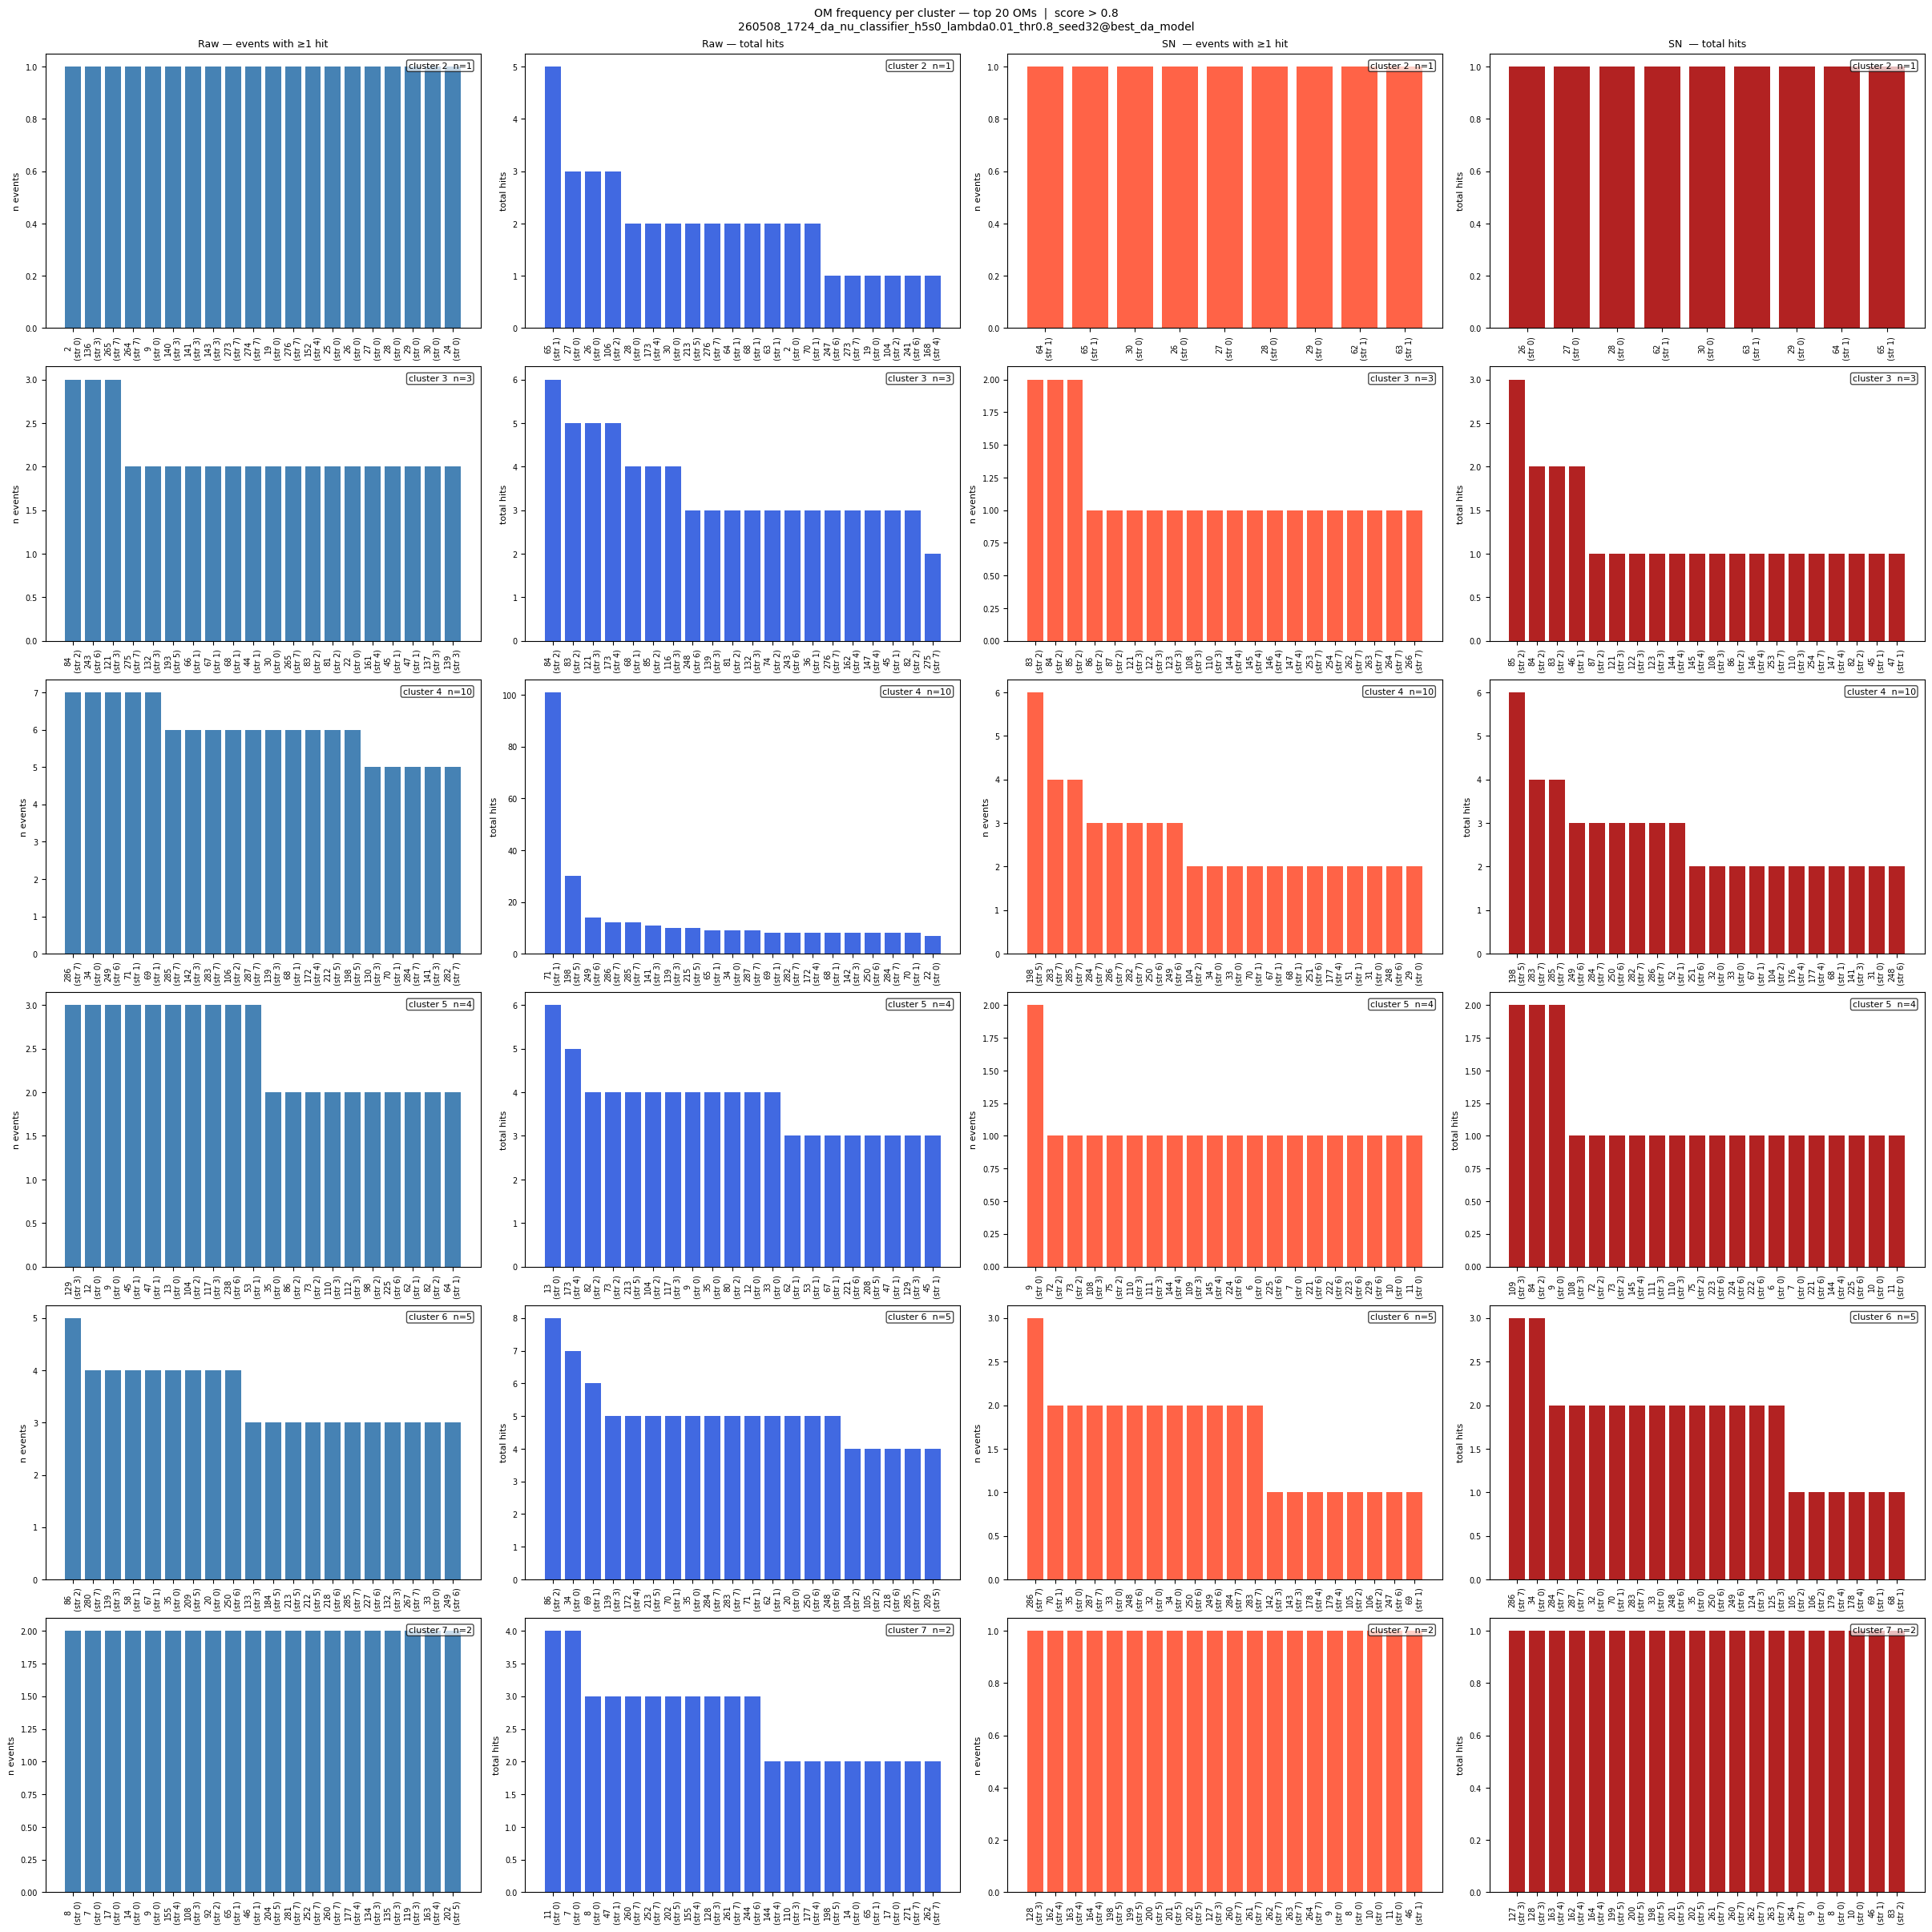

In [38]:
# ── OM frequency per cluster (raw & SN channels, high-score exp) ───────
from collections import Counter

N_TOP_OM = 20
clusters  = sorted(df_hi["cluster"].unique())
n_clust   = len(clusters)

# ── OM-level plots: n_clusters rows × 4 columns ───────────────────────
fig, axes = plt.subplots(
    n_clust, 4,
    figsize=(24, 4 * n_clust),
    constrained_layout=True,
)
if n_clust == 1:
    axes = axes[np.newaxis, :]

COL_CFG = [
    ("raw_channels", False, "Raw — events with ≥1 hit",  "steelblue"),
    ("raw_channels", True,  "Raw — total hits",           "royalblue"),
    ("sn_channels",  False, "SN  — events with ≥1 hit",  "tomato"),
    ("sn_channels",  True,  "SN  — total hits",           "firebrick"),
]

for row_i, (clust, sub) in enumerate(df_hi.groupby("cluster")):
    counters = {}
    for col in ("raw_channels", "sn_channels"):
        hit_c = Counter()
        ev_c  = Counter()
        for arr in sub[col]:
            lst = arr.tolist()
            hit_c.update(lst)
            ev_c.update(set(lst))
        counters[(col, True)]  = hit_c
        counters[(col, False)] = ev_c

    for col_i, (col, use_hits, title, color) in enumerate(COL_CFG):
        ax  = axes[row_i, col_i]
        cnt = counters[(col, use_hits)]
        top = pd.Series(cnt).sort_values(ascending=False).head(N_TOP_OM)

        ax.bar(range(len(top)), top.values, color=color)
        ax.set_xticks(range(len(top)))
        ax.set_xticklabels(
            [f"{ch}\n(str {ch // STRING_DIVISOR})" for ch in top.index],
            rotation=90, fontsize=6,
        )
        ax.set_ylabel("total hits" if use_hits else "n events", fontsize=8)
        ax.tick_params(labelsize=7)
        if row_i == 0:
            ax.set_title(title, fontsize=9)
        ax.text(0.98, 0.97, f"cluster {clust}  n={len(sub):,}",
                transform=ax.transAxes, ha="right", va="top", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

fig.suptitle(
    f"OM frequency per cluster — top {N_TOP_OM} OMs  |  score > {SCORE_THR}\n{ckpt_name}",
    fontsize=10,
)
plt.show()


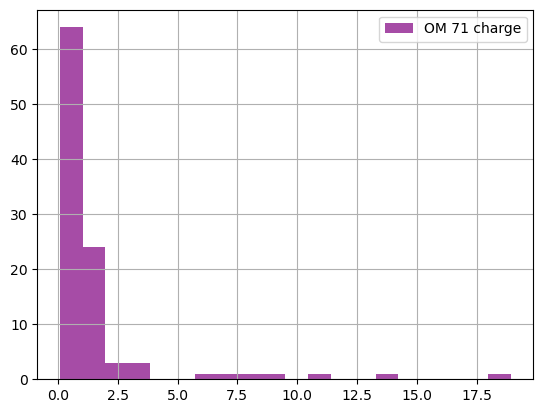

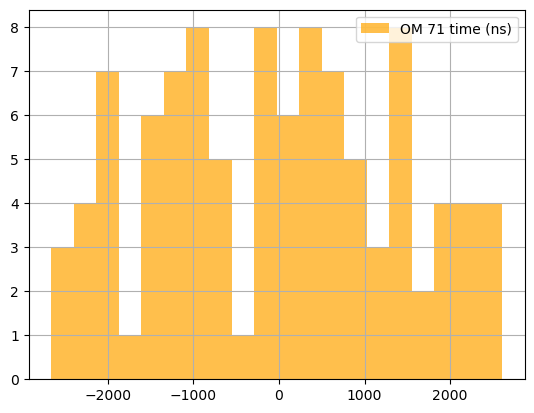

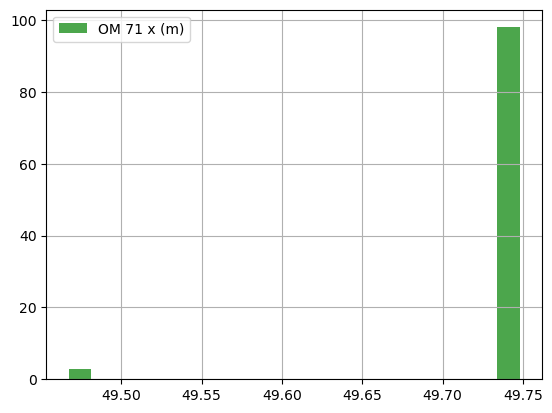

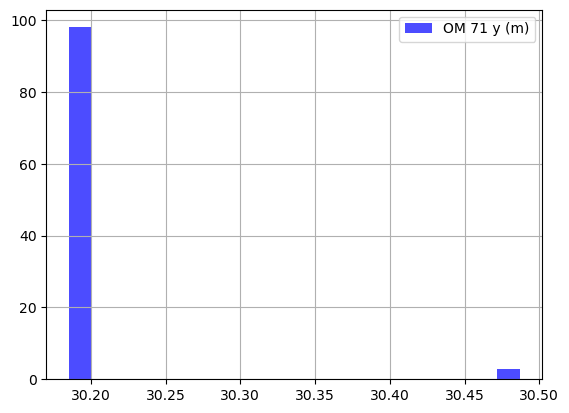

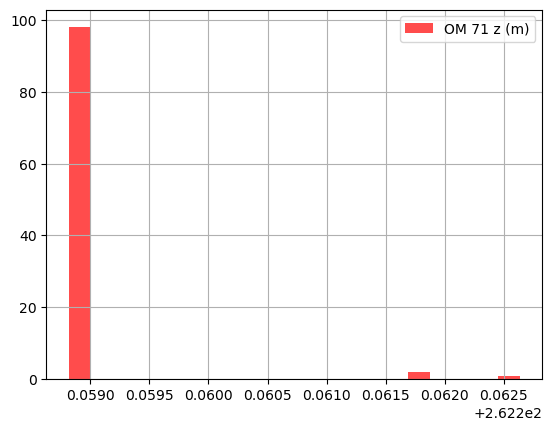

In [62]:
mask = df_hi["cluster"] == 4
mask &= df_hi["raw_channels"].apply(lambda x: 71 in x)
strange_71_channel = df_hi[mask].apply(lambda row: row['raw_hits'][row['raw_channels'] == 71], axis=1).explode()
strange_71_channel.apply(lambda x: x[0]).hist(bins=20, label="OM 71 charge", color="purple", alpha=0.7)
plt.legend()
plt.show()
strange_71_channel.apply(lambda x: x[1]).hist(bins=20, label="OM 71 time (ns)", color="orange", alpha=0.7)
plt.legend()
plt.show()

strange_71_channel.apply(lambda x: x[2]).hist(bins=20, label="OM 71 x (m)", color="green", alpha=0.7)
plt.legend()
plt.show()

strange_71_channel.apply(lambda x: x[3]).hist(bins=20, label="OM 71 y (m)", color="blue", alpha=0.7)
plt.legend()
plt.show()

strange_71_channel.apply(lambda x: x[4]).hist(bins=20, label="OM 71 z (m)", color="red", alpha=0.7)
plt.legend()
plt.show()

In [35]:
i = 7
df_hi.iloc[i]#['sn_hits']

event_fk                                                  656699471
score                                                      0.918939
n_sn_hits                                                        12
n_sn_strings                                                      3
season                                                         2020
run_num                                                         325
event_id                                                       7175
cluster                                                           6
h5_path           /home/albert/Baikal2025/data_manager/data/h5da...
part_key                                       part_s2020_c06_r0325
local_idx                                                      7175
n_raw_hits                                                       95
n_raw_strings                                                     8
q_max                                                     11.997887
q_mean                                          

In [ ]:
# # ── Score vs key features (scatter) ──────────────────────────────────
# SCATTER = [
#     ("n_raw_hits",  "n raw hits",   False),
#     ("q_max",       "Q max (raw)",  True),
#     ("q_sum",       "Q sum (raw)",  True),
#     ("t_std",       "t std (ns)",   False),
#     ("t_range",     "t range (ns)", False),
#     ("sn_ratio",    "SN ratio",     False),
# ]
#
# fig, axes = plt.subplots(2, 3, figsize=(16, 9))
# axes = axes.flatten()
# for i, (col, xlabel, log_y) in enumerate(SCATTER):
#     ax = axes[i]
#     for df_g, label, color in [
#         (stats_exp, "Exp",      "steelblue"),
#         (stats_mc,  "MC muatm", "tomato"),
#     ]:
#         sub = df_g[["score", col]].dropna()
#         ax.scatter(sub.score, sub[col], s=3, alpha=0.25,
#                    color=color, label=label, rasterized=True)
#     ax.axvline(SCORE_THR, color="black", lw=1, ls="--", alpha=0.5)
#     ax.set_xlabel("nu-classifier score", fontsize=9)
#     ax.set_ylabel(xlabel, fontsize=9)
#     if log_y:
#         ax.set_yscale("log")
#     ax.tick_params(labelsize=8)
#
# axes[0].legend(fontsize=8, markerscale=4)
# fig.suptitle(f"Score vs features  |  {ckpt_name}", fontsize=10)
# plt.tight_layout()
# plt.show()

In [ ]:
# # ── Summary statistics table ──────────────────────────────────────────
# STAT_COLS = [
#     "n_raw_hits", "n_raw_strings", "n_sn_hits", "n_sn_strings", "sn_ratio",
#     "q_max", "q_mean", "q_std", "q_sum", "q_p99",
#     "t_std", "t_range",
#     "x_std", "y_std", "z_std", "spatial_std",
# ]

# def _summarise(df, name):
#     s = df[STAT_COLS].agg(["mean", "median", "std"]).T
#     s.columns = [f"{name}_{c}" for c in s.columns]
#     return s

# tbl = pd.concat([
#     _summarise(exp_hi, "exp_hi"),
#     _summarise(mc_hi,  "mc_hi"),
# ], axis=1)
# tbl["ratio_mean (exp/mc)"] = tbl["exp_hi_mean"] / tbl["mc_hi_mean"]

# pd.set_option("display.float_format", "{:.3g}".format)
# print(f"High-score events  (score > {SCORE_THR})  "
#       f"—  Exp n={len(exp_hi):,}   MC muatm n={len(mc_hi):,}")
# display(tbl)

High-score events  (score > 0.8)  —  Exp n=25   MC muatm n=470


,exp_hi_mean,exp_hi_median,exp_hi_std,mc_hi_mean,mc_hi_median,mc_hi_std,ratio_mean (exp/mc)
n_raw_hits,84.7,84,19.3,73.8,73,12.5,1.15
n_raw_strings,7.88,8,0.332,7.84,8,0.365,1
n_sn_hits,12.3,11,4,10.8,9.5,3.86,1.15
n_sn_strings,3.76,4,1.33,3.22,3,1.09,1.17
sn_ratio,0.147,0.138,0.041,0.147,0.136,0.0459,0.999
q_max,177,32,237,145,17.9,785,1.22
q_mean,3.57,2.05,2.84,3.35,1.47,10.7,1.07
q_std,18.6,4.32,23.8,17.2,2.52,89.5,1.08
q_sum,321,147,287,249,111,804,1.29
q_p99,35.9,19,38.8,50.6,12,212,0.711


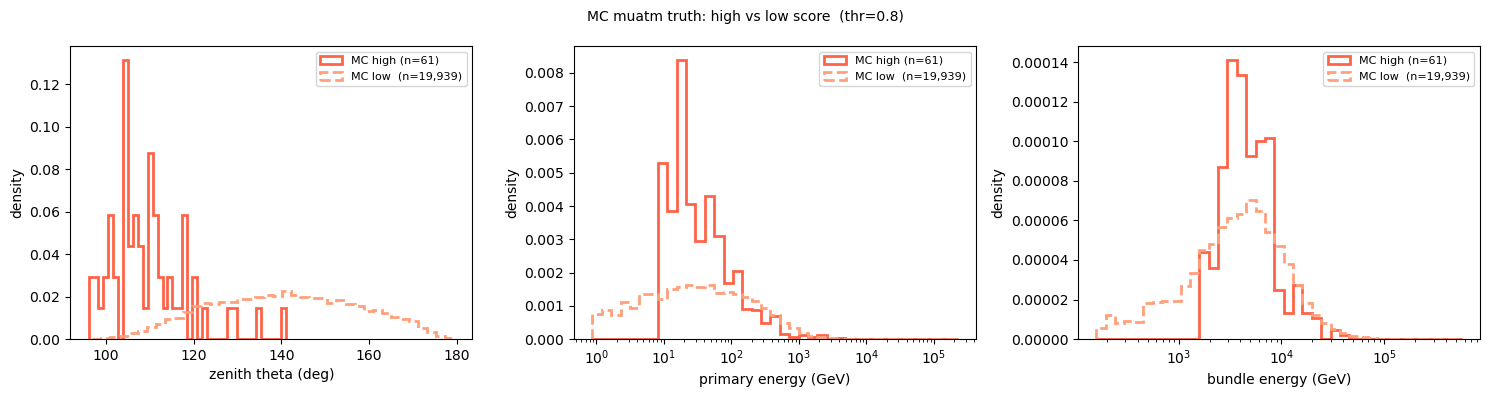

In [17]:
# ── MC truth: energy / zenith for high vs low score ───────────────────
if "theta" in stats_mc.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, col, xlabel, log_x in [
        (axes[0], "theta",          "zenith theta (deg)",   False),
        (axes[1], "energy_primary", "primary energy (GeV)", True),
        (axes[2], "energy_bundle",  "bundle energy (GeV)",  True),
    ]:
        hi_v = mc_hi[col].dropna(); lo_v = mc_lo[col].dropna()
        all_v = pd.concat([hi_v, lo_v])
        if log_x:
            kw_bins = dict(bins=np.logspace(np.log10(max(all_v.min(), 1e-3)),
                                            np.log10(all_v.max()), 40))
            ax.set_xscale("log")
        else:
            kw_bins = dict(bins=40)
        kw = dict(**kw_bins, density=True, histtype="step", linewidth=2)
        ax.hist(hi_v, **kw, color="tomato",      label=f"MC high (n={len(hi_v):,})")
        ax.hist(lo_v, **kw, color="lightsalmon", label=f"MC low  (n={len(lo_v):,})", ls="--")
        ax.set_xlabel(xlabel); ax.set_ylabel("density")
        ax.legend(fontsize=8)
    fig.suptitle(f"MC muatm truth: high vs low score  (thr={SCORE_THR})", fontsize=10)
    plt.tight_layout()
    plt.show()

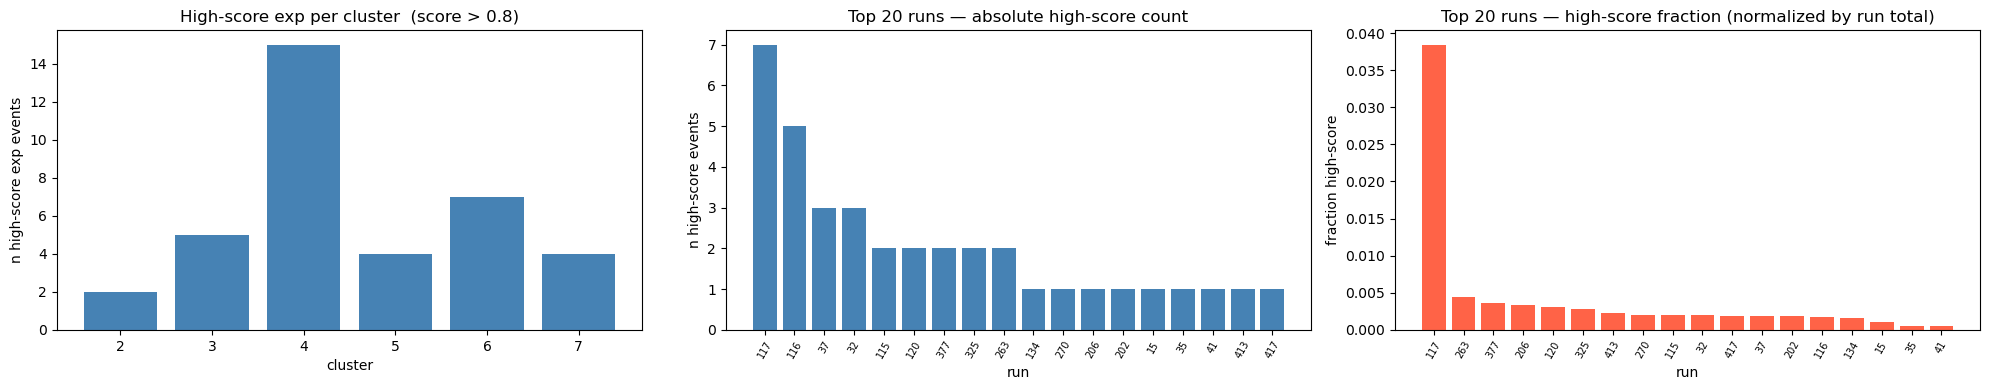

In [18]:
# ── Exp metadata: do high-score events cluster in specific runs? ──────
if "cluster" in df_exp_feat.columns:
    meta_hi = df_exp_feat.query("score > @SCORE_THR")

    fig, axes = plt.subplots(1, 3, figsize=(20, 4))

    by_clust = meta_hi.groupby("cluster").size().sort_index()
    axes[0].bar(by_clust.index.astype(str), by_clust.values, color="steelblue")
    axes[0].set_xlabel("cluster")
    axes[0].set_ylabel("n high-score exp events")
    axes[0].set_title(f"High-score exp per cluster  (score > {SCORE_THR})")

    # Absolute count per run (top 20)
    hi_per_run  = meta_hi.groupby("run_num").size()
    by_run_abs  = hi_per_run.sort_values(ascending=False).head(20)
    axes[1].bar(by_run_abs.index.astype(str), by_run_abs.values, color="steelblue")
    axes[1].set_xlabel("run")
    axes[1].set_ylabel("n high-score events")
    axes[1].set_title("Top 20 runs — absolute high-score count")
    axes[1].tick_params(axis="x", rotation=60, labelsize=7)

    # Normalised: fraction of events in each run that score above threshold.
    # Denominator = all exp events from the full query (quality-filtered).
    total_per_run = df_exp.groupby("run_num").size()
    frac_per_run  = (hi_per_run / total_per_run).dropna().sort_values(ascending=False).head(20)
    axes[2].bar(frac_per_run.index.astype(str), frac_per_run.values, color="tomato")
    axes[2].set_xlabel("run")
    axes[2].set_ylabel("fraction high-score")
    axes[2].set_title("Top 20 runs — high-score fraction (normalized by run total)")
    axes[2].tick_params(axis="x", rotation=60, labelsize=7)

    plt.tight_layout()
    plt.show()

Loading channels for 37 high-score exp events ...


loading channels:   0%|          | 0/18 [00:00<?, ?it/s]

Unique channels seen: 288


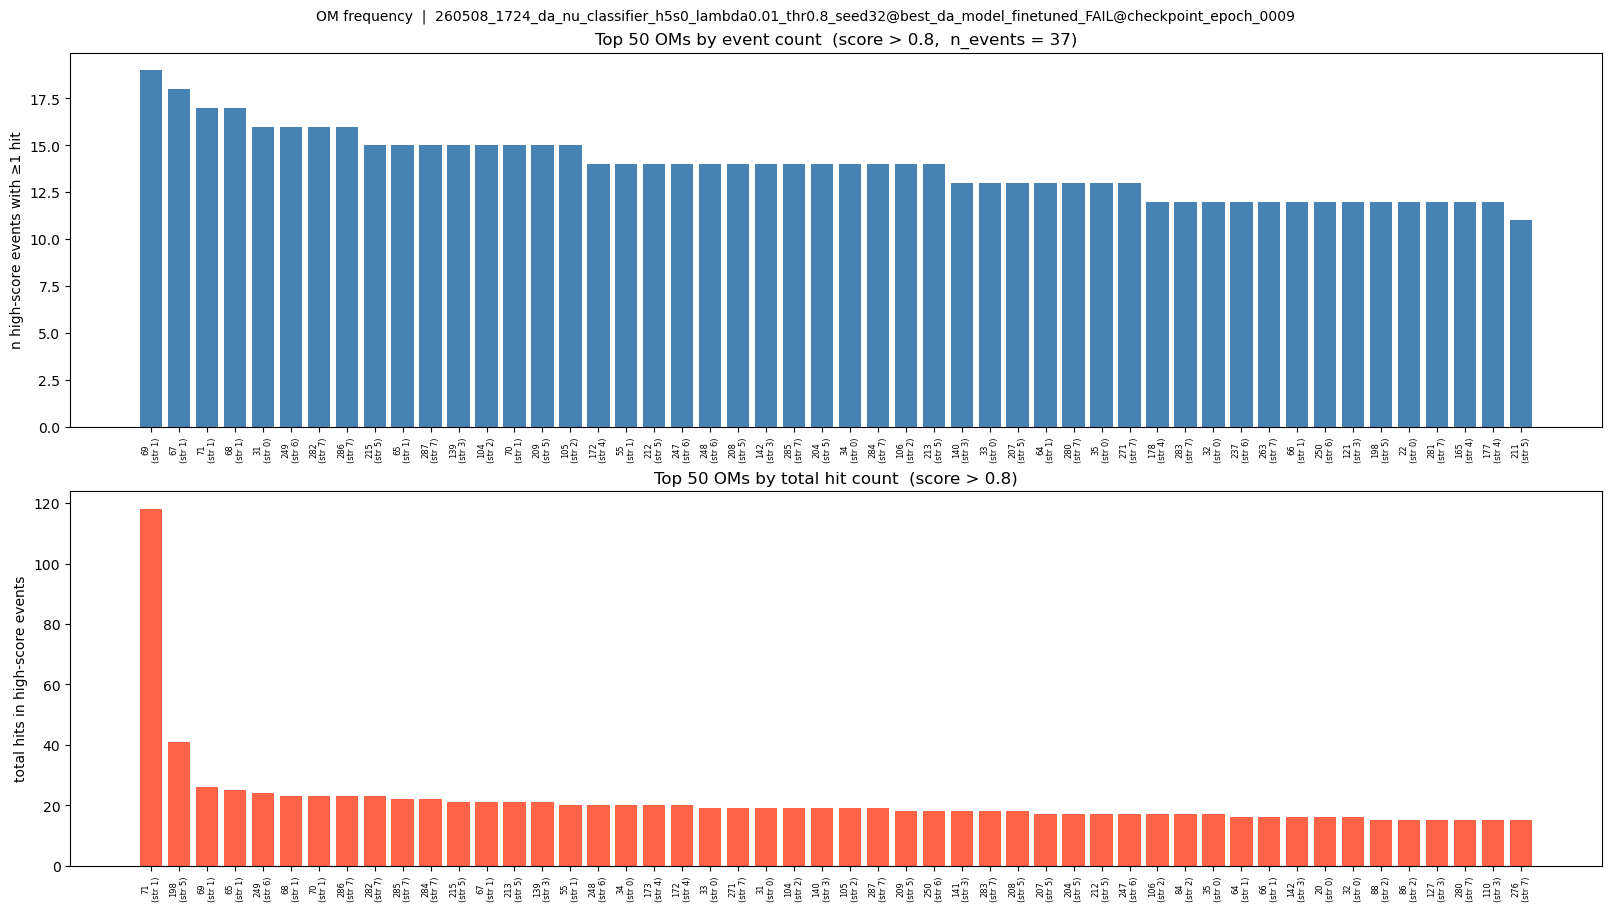

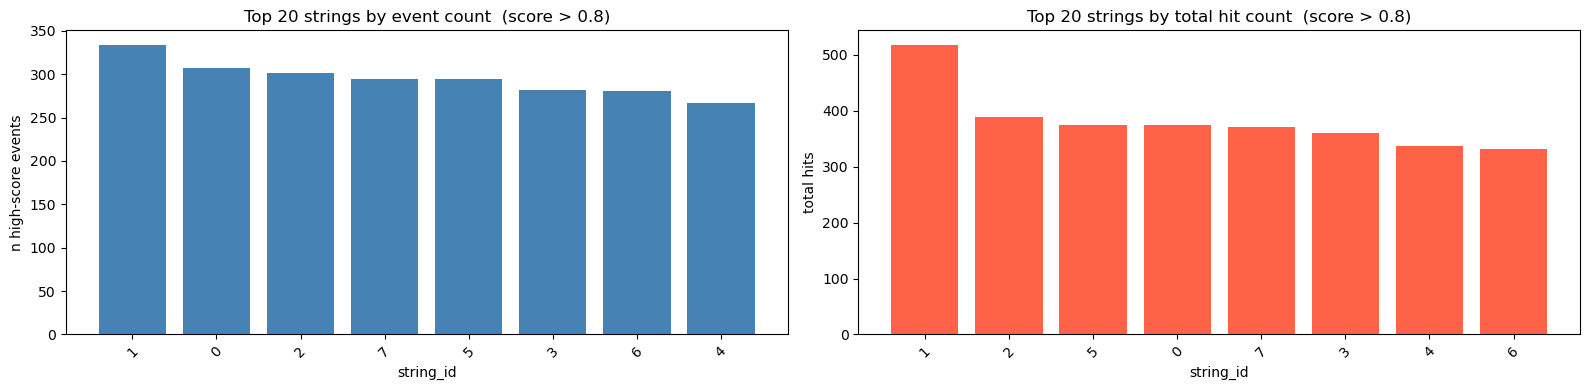

In [19]:
# ── OM (channel) frequency in high-score Exp events ───────────────────
# Which optical modules appear most often across high-score exp events?
# Two metrics: events-with-hit (how many events fire this OM) and
# total hit count (total pulses from this OM across all high-score events).
from collections import Counter


def _collect_channel_counts(df_h5: pd.DataFrame, grp_name: str) -> tuple[Counter, Counter]:
    """Return (hit_counter, event_counter) per channel_id for events in df_h5."""
    hit_counter   = Counter()
    event_counter = Counter()
    for (h5_path, part_key), grp in tqdm(
        df_h5.groupby(["h5_path", "part_key"], sort=True), desc="loading channels"
    ):
        with h5py.File(h5_path, "r") as f:
            h5g       = f[grp_name]
            ev_starts = h5g[f"raw/ev_starts/{part_key}/data"][:].astype(np.int64)
            channels  = h5g[f"raw/channels/{part_key}/data"][:].astype(np.int32)
        for row in grp.itertuples(index=False):
            li   = int(row.local_idx)
            s, e = int(ev_starts[li]), int(ev_starts[li + 1])
            chans = channels[s:e]
            hit_counter.update(chans.tolist())
            event_counter.update(set(chans.tolist()))
    return hit_counter, event_counter


# Filter df_exp_feat to high-score events only (avoids reloading low-score events)
hi_fks       = set(exp_hi.event_fk)
df_exp_hi_h5 = df_exp_feat[df_exp_feat.event_fk.isin(hi_fks)]

print(f"Loading channels for {len(df_exp_hi_h5):,} high-score exp events ...")
hit_cnt, ev_cnt = _collect_channel_counts(df_exp_hi_h5, grp_name="exp")
print(f"Unique channels seen: {len(ev_cnt):,}")

N_TOP = 50

top_by_events = pd.Series(ev_cnt).sort_values(ascending=False).head(N_TOP)
top_by_hits   = pd.Series(hit_cnt).sort_values(ascending=False).head(N_TOP)

fig, axes = plt.subplots(2, 1, figsize=(16, 9), constrained_layout=True)

ax = axes[0]
ax.bar(range(len(top_by_events)), top_by_events.values, color="steelblue")
ax.set_xticks(range(len(top_by_events)))
ax.set_xticklabels(
    [f"{ch}\n(str {ch // STRING_DIVISOR})" for ch in top_by_events.index],
    rotation=90, fontsize=6,
)
ax.set_ylabel("n high-score events with ≥1 hit")
ax.set_title(
    f"Top {N_TOP} OMs by event count  "
    f"(score > {SCORE_THR},  n_events = {len(exp_hi):,})"
)

ax = axes[1]
ax.bar(range(len(top_by_hits)), top_by_hits.values, color="tomato")
ax.set_xticks(range(len(top_by_hits)))
ax.set_xticklabels(
    [f"{ch}\n(str {ch // STRING_DIVISOR})" for ch in top_by_hits.index],
    rotation=90, fontsize=6,
)
ax.set_ylabel("total hits in high-score events")
ax.set_title(f"Top {N_TOP} OMs by total hit count  (score > {SCORE_THR})")

plt.suptitle(f"OM frequency  |  {ckpt_name}", fontsize=10)
plt.show()

# ── Per-string summary ─────────────────────────────────────────────────
string_ev_cnt  = Counter()
string_hit_cnt = Counter()
for ch, cnt in ev_cnt.items():
    string_ev_cnt[ch // STRING_DIVISOR]  += cnt
for ch, cnt in hit_cnt.items():
    string_hit_cnt[ch // STRING_DIVISOR] += cnt

top_str_ev  = pd.Series(string_ev_cnt).sort_values(ascending=False).head(20)
top_str_hit = pd.Series(string_hit_cnt).sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, data, ylabel, color in [
    (axes[0], top_str_ev,  "n high-score events",  "steelblue"),
    (axes[1], top_str_hit, "total hits",            "tomato"),
]:
    ax.bar(data.index.astype(str), data.values, color=color)
    ax.set_xlabel("string_id")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
axes[0].set_title(f"Top 20 strings by event count  (score > {SCORE_THR})")
axes[1].set_title(f"Top 20 strings by total hit count  (score > {SCORE_THR})")
plt.tight_layout()
plt.show()